In [1]:
import pyreadr

# Load the rds file
result = pyreadr.read_r('06_Cb_BTM_table.rds')

# pyreadr returns a dictionary; the data is usually under the 'None' key 
# because rds files contain a single object without a specific name.
df = result[None]

# Show all columns

print("-"*50+"Columns name"+50*"-")
print(df.columns)
print("-"*50+"Columns name"+50*"-")
print()


--------------------------------------------------Columns name--------------------------------------------------
Index(['segment_id', 'gene', 'karyotype', 'sample_id', 'NV', 'DP',
       'mutatation_status', 'mult_estimate', 'mutation_call', 'timed',
       'segment_name', 'sample', 'n_mutations', 'clock_mean', 'clock_low',
       'clock_high', 'clock_rank', 'class', 'is_WGD', 'ploidy', 'purity',
       'best_K', 'ttype'],
      dtype='object')
--------------------------------------------------Columns name--------------------------------------------------



In [2]:
# Show values of category columns
print("-"*50+"Labels values"+50*"-")
for col in df.columns:
    if(len(df[col].unique())<100 ):
        print(col + ": " + str(df[col].unique()))
print("-"*50+"Labels values"+50*"-")
print()

--------------------------------------------------Labels values--------------------------------------------------
karyotype: ['2:2' '2:0' '2:1' '4:2' '3:0' '1:0' '5:0' '11:0' '4:4' '1:1' '4:0' '3:1'
 '6:2' '7:3' '3:2' '3:3']
NV: [ nan  17.   8.  10.  24.   9.  15.  16.  13.  11.  18.  25.  14.  20.
  26.  22.  37.  32.  28.  27.  21.  23.  55.  31.   7.  12.  30.  44.
  47.   5.  36.  56.  41.  33.  29.  46.   4.  40.  35.  51.  19.   6.
  34.   3.  48.  81.  53.  57.  54.  42.  39.  43.  65.  38.  70.  49.
  52.  45.  50.  71.  58. 133. 103.]
mutatation_status: ['WT' 'M' 'CI_M' 'CNA_driver']
mult_estimate: [nan  1.  2.]
mutation_call: [nan 'in PCAWG driver annotation' 'in PCAWG driver annotation but missing']
timed: [ True]
clock_rank: [1 2 3 nan 4 5]
class: ['WGD' 'HM' 'Classic']
is_WGD: ['wgd' 'no_wgd']
ploidy: [3. 2. 4. 5. 6. 1.]
best_K: [1. 3. 2. 4. 5.]
ttype: ['OV' 'LINC' 'MALY' 'LIRI' 'RECA' 'PACA' 'PAEN' 'PBCA' 'SKCM' 'COAD'
 'MELA' 'LUAD' 'LUSC' 'PRAD' 'UCEC' 'ESAD' 'CLLE' 'GA

In [3]:
# Drop subjects with best_K equals to 1

print("Starting samples: " + str(len(df["sample_id"].unique())))

df = df[df["best_K"] != 1]

print("Remaining samples: " + str(len(df["sample_id"].unique())))

Starting samples: 1002
Remaining samples: 189


In [13]:
# Craete graph
import networkx as nx

# import dictionary for graph
from collections import defaultdict

# for permutations
from itertools import product

# Just make the df with only worth keep
df = df[["sample_id", "clock_rank", "gene", "best_K"]]

graph = defaultdict(int)

for sample in df["sample_id"].unique():

    df_sample = df[df["sample_id"] == sample]  # Filter for specific sample

    for i in range(df_sample["clock_rank"].nunique() - 1):
        genes_before = df_sample[df_sample["clock_rank"] == i + 1][
            "gene"
        ].unique()  # why same mutation write it more than once?
        genes_after = df_sample[df_sample["clock_rank"] == i + 2]["gene"].unique()

        comb = product(genes_after, genes_after)

        for edge in comb:
            graph[(edge[0], edge[1])] += 1

edges = []

print("Numero di archi ",len(graph))
for k, v in graph.items():
    if k[0] == k[1]:
        continue
    if v<40:
        continue
    edges.append((k[0], k[1], v))
print("Numero di archi rilevanti",len(edges))


G = nx.DiGraph()

G.add_weighted_edges_from(edges)

Numero di archi  238613
Numero di archi rilevanti 20


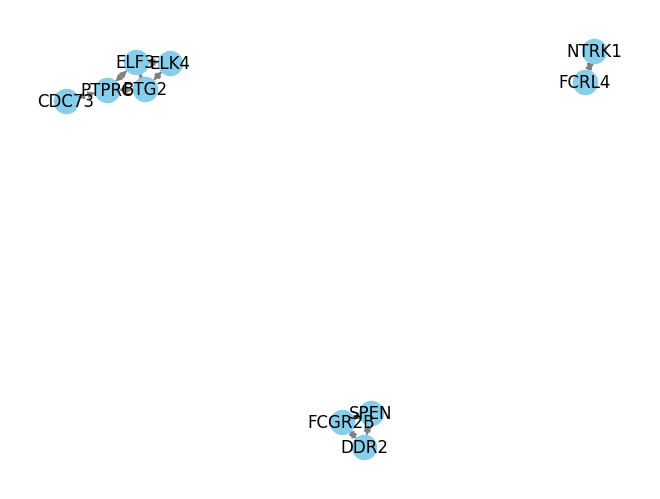

In [14]:
# basic plot
import matplotlib.pyplot as plt


# 4. Visualize it (requires matplotlib)
nx.draw(G, with_labels=True, node_color='skyblue', edge_color='gray')
plt.show()